In [ ]:
# Extract, filter and compile datasets

import pandas as pd

def exfilter(date,i,n):
    """Extract and filter the dataset from an individual file as a pandas DataFrame."""
    # Construct the file suffix, accounting for single-digit and double-digit part numbers
    if n > 9:
        z = ""
    else:
        z = "0"
    # Read DataFrame
    df = pd.read_stata(f'output_{str(date[i])}_part-000{z+str(n)}.dta')
    df_length=len(df)
    # Filter for Engineering + Internship/Placement
    fdf=df[
            df["title"].str.contains(r"\binterns?\b|\binternships?\b|\bplacements?\b", case=False, na=False)
            & df["title"].str.contains(r"engineer", case=False, na=False)
        ]
    return fdf, df_length

# Dates corresponding to the selected dataset snapshots
date = (
    '2022_10_2', '2023_1_1', '2023_4_2', '2023_7_5',
    '2023_10_1', '2024_1_7', '2024_4_7', '2024_7_7',
    '2024_10_6', '2025_1_5', '2025_4_6', '2025_7_6'
)

relevance = []
fdf_length = []

for i in range(len(date)):
    df_length = 0
    fdf = []
    # Define the range of dataset parts for each snapshot
    if i == 0:
        x=0
        y=7
    elif i == 1:
        x=2
        y=10
    elif i in (6,7,8,10):
        x=0
        y=11
    elif i == 11:
        x=0
        y=12
    else:
        x=0
        y=10

    # Extract and filter each dataset part
    for n in range(x,y):
        fdf_n, df_length_n = exfilter(date, i, n)
        fdf.append(fdf_n)
        df_length += df_length_n

    # Combine filtered dataset parts into a single DataFrame
    fdf = pd.concat(fdf, ignore_index=True)
    fdf_length.append(len(fdf))
    relevance.append(round(len(fdf)/df_length*100,3))

    print(f"Filtered dataset for {date[i]}: {len(fdf)} of {df_length} ({relevance[i]}%)")

    # Save the filtered dataset for the current snapshot
    fdf.to_csv(f"fdf_{date[i]}.csv", index=False)

print("\nFilter completed.")

Filtered Dataset for 2022_10_2: 576 of 1083525 (0.053%)
Filtered Dataset for 2023_1_1: 842 of 894938 (0.094%)
Filtered Dataset for 2023_4_2: 624 of 1059672 (0.059%)
Filtered Dataset for 2023_7_5: 250 of 1064712 (0.023%)
Filtered Dataset for 2023_10_1: 886 of 1092172 (0.081%)
Filtered Dataset for 2024_1_7: 1055 of 797452 (0.132%)
Filtered Dataset for 2024_4_7: 490 of 863310 (0.057%)
Filtered Dataset for 2024_7_7: 90 of 861690 (0.01%)
Filtered Dataset for 2024_10_6: 546 of 879442 (0.062%)
Filtered Dataset for 2025_1_5: 409 of 743726 (0.055%)
Filtered Dataset for 2025_4_6: 330 of 855353 (0.039%)
Filtered Dataset for 2025_7_6: 169 of 883207 (0.019%)

Filter Completed.


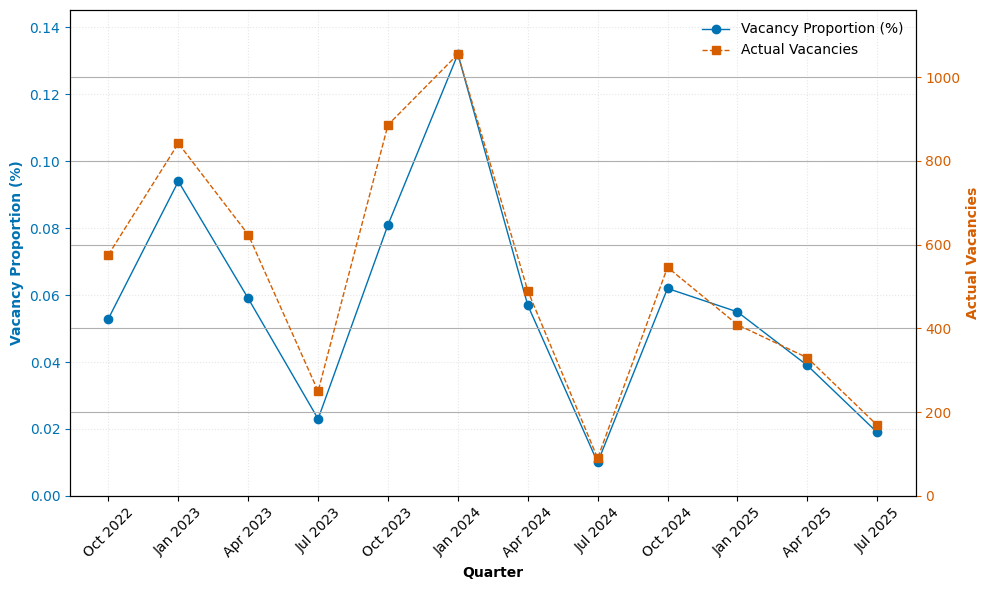

In [ ]:
# Line Plot

import matplotlib.pyplot as plt

# Labels for each quarter (snapshot date)
labels = [
    "Oct 2022", "Jan 2023", "Apr 2023", "Jul 2023",
    "Oct 2023", "Jan 2024", "Apr 2024", "Jul 2024",
    "Oct 2024", "Jan 2025", "Apr 2025", "Jul 2025"
]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Define colours
relevance_colour = "#0072B2"
fdf_colour = "#D55E00"

# Left axis: vacancy proportion
ax1.plot(
    labels,
    relevance,
    color=relevance_colour,
    linestyle="-",
    marker="o",
    linewidth=1,
    markersize=6
)
ax1.set_ylabel(
    "Vacancy Proportion (%)",
    color=relevance_colour,
    fontweight='bold'
)
ax1.set_ylim(
    0,
    max(relevance) * 1.1
)

ax1.set_xlabel("Quarter", fontweight='bold')

ax1.tick_params(
    axis="y",
    colors=relevance_colour
)

# Right axis: number of filtered vacancies
ax2 = ax1.twinx()
ax2.plot(
    labels,
    fdf_length,
    color=fdf_colour,
    linestyle="--",
    marker="s",
    linewidth=1,
    markersize=6
)
ax2.set_ylabel(
    "Actual Vacancies",
    color=fdf_colour,
    fontweight='bold'
)
ax2.set_ylim(
    0,
    max(fdf_length) * 1.1
)
ax2.tick_params(
    axis="y",
    colors=fdf_colour
)

# Combine lines from both axes into a single legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(
    lines,
    ["Vacancy Proportion (%)",
     "Actual Vacancies"],
    loc="best",
    frameon=False
)

# Format x-axis labels
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45)

# Gridlines
ax1.grid(
    True,
    alpha=0.3,
    linestyle=":"
)

fig.tight_layout()

plt.savefig(
    "fdf_vsrs_line.svg",
    format="svg",
    bbox_inches="tight"
)

In [ ]:
# Combine dataset

import pandas as pd

# Dates corresponding to the selected dataset snapshots
date = (
    '2022_10_2', '2023_1_1', '2023_4_2', '2023_7_5',
    '2023_10_1', '2024_1_7', '2024_4_7', '2024_7_7',
    '2024_10_6', '2025_1_5', '2025_4_6', '2025_7_6'
)

fdfs = []

for i in range(0, len(date)):
    df = pd.read_csv(f"fdf_{date[i]}.csv")
    # Record the snapshot date/quarter associated with each record
    df["quarter"] = date[i]
    fdfs.append(df)

# Combine data from all snapshot dates into a single dataset
fdf_all = pd.concat(fdfs, ignore_index=True)

print(f"Combined dataset of size: {len(fdf_all)}")

# Save the combined dataset
fdf_all.to_csv("fdf_all.csv", index=False)

Combined dataset of size: 6267


In [1]:
# VSRS

import pandas as pd
import re

def vsrs(description):
    """Extract visa/sponsorship/right-to-work statements (VSRS)."""

    keywords = [
        "visa",
        "sponsor",
        "right to live and work",
        "right to work",
        "eligible to work",
        "eligibility to work",
        "work eligibility",
        "authorised to work",
        "authorisation to work",
        "authorized to work",
        "authorization to work",
        "working right",
        "work authorisation",
        "work authorization",
        "permission to work",
        "work permit",
        "working permit",
        "work permission",
        "working permission",
    ]

    statements = []

    # Split the description into sentences and bullet-point statements
    sentences = re.split(r'(?<=[.!?])\s+|\s*[-*+·•]\s*', description)

    # Find and store statements containing at least one VSRS keyword
    for sentence in sentences:
        if any(keyword in sentence.lower() for keyword in keywords):
            statements.append(sentence.strip())

    # Return combined statement(s) and remove duplicates (preserving original order)
    return " ".join(dict.fromkeys(statements)) or "Not found"

# Extract VSRS statements to new column and create a separate dataset containing only jobs with VSRS
df = pd.read_csv("fdf_all.csv")
df["vsrs"] = df["description"].apply(vsrs)
vsrs_df = df[df["vsrs"] != "Not found"].copy()

# Determining the number of jobs with VSRS
vsrs_jobs = (df["vsrs"] != "Not found").sum()
print(f"Jobs with VSRS: {vsrs_jobs} of {len(df)}")

# Save the complete dataset with the VSRS column
df.to_csv("fdf_all_vsrs_applied.csv", index=False)
# Save only the jobs containing VSRS statements
vsrs_df.to_csv("fdf_all_vsrs_filtered.csv", index=False)

Jobs with VSRS: 1640 of 6267
